In [5]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [6]:
# EDA: Explore Data Structure
data_dir = 'data/genres_original'

# Get all genres and WAV files
genres = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
print(f"Genres found: {genres}\n")

# Collect file information
file_info = []
for genre in genres:
    genre_path = os.path.join(data_dir, genre)
    wav_files = [f for f in os.listdir(genre_path) if f.endswith('.wav')]
    
    for wav_file in wav_files:
        file_path = os.path.join(genre_path, wav_file)
        try:
            y, sr = librosa.load(file_path, sr=None)
            duration = librosa.get_duration(y=y, sr=sr)
            file_info.append({
                'Genre': genre,
                'Filename': wav_file,
                'Duration (s)': duration,
                'Sample Rate': sr,
                'Sample Count': len(y)
            })
        except Exception as e:
            print(f"Error loading {file_path}: {e}")

# Create DataFrame
df = pd.DataFrame(file_info)
print(f"Total files: {len(df)}")
print(f"\nFiles per genre:\n{df['Genre'].value_counts().sort_index()}")
print(f"\nData summary:")
print(df.describe())

Genres found: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Error loading data/genres_original\jazz\jazz.00054.wav: 
Total files: 999

Files per genre:
Genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz          99
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64

Data summary:
       Duration (s)  Sample Rate   Sample Count
count    999.000000        999.0     999.000000
mean      30.024071      22050.0  662030.764765
std        0.080951          0.0    1784.965742
min       29.931973      22050.0  660000.000000
25%       30.000181      22050.0  661504.000000
50%       30.013333      22050.0  661794.000000
75%       30.013333      22050.0  661794.000000
max       30.648889      22050.0  675808.000000


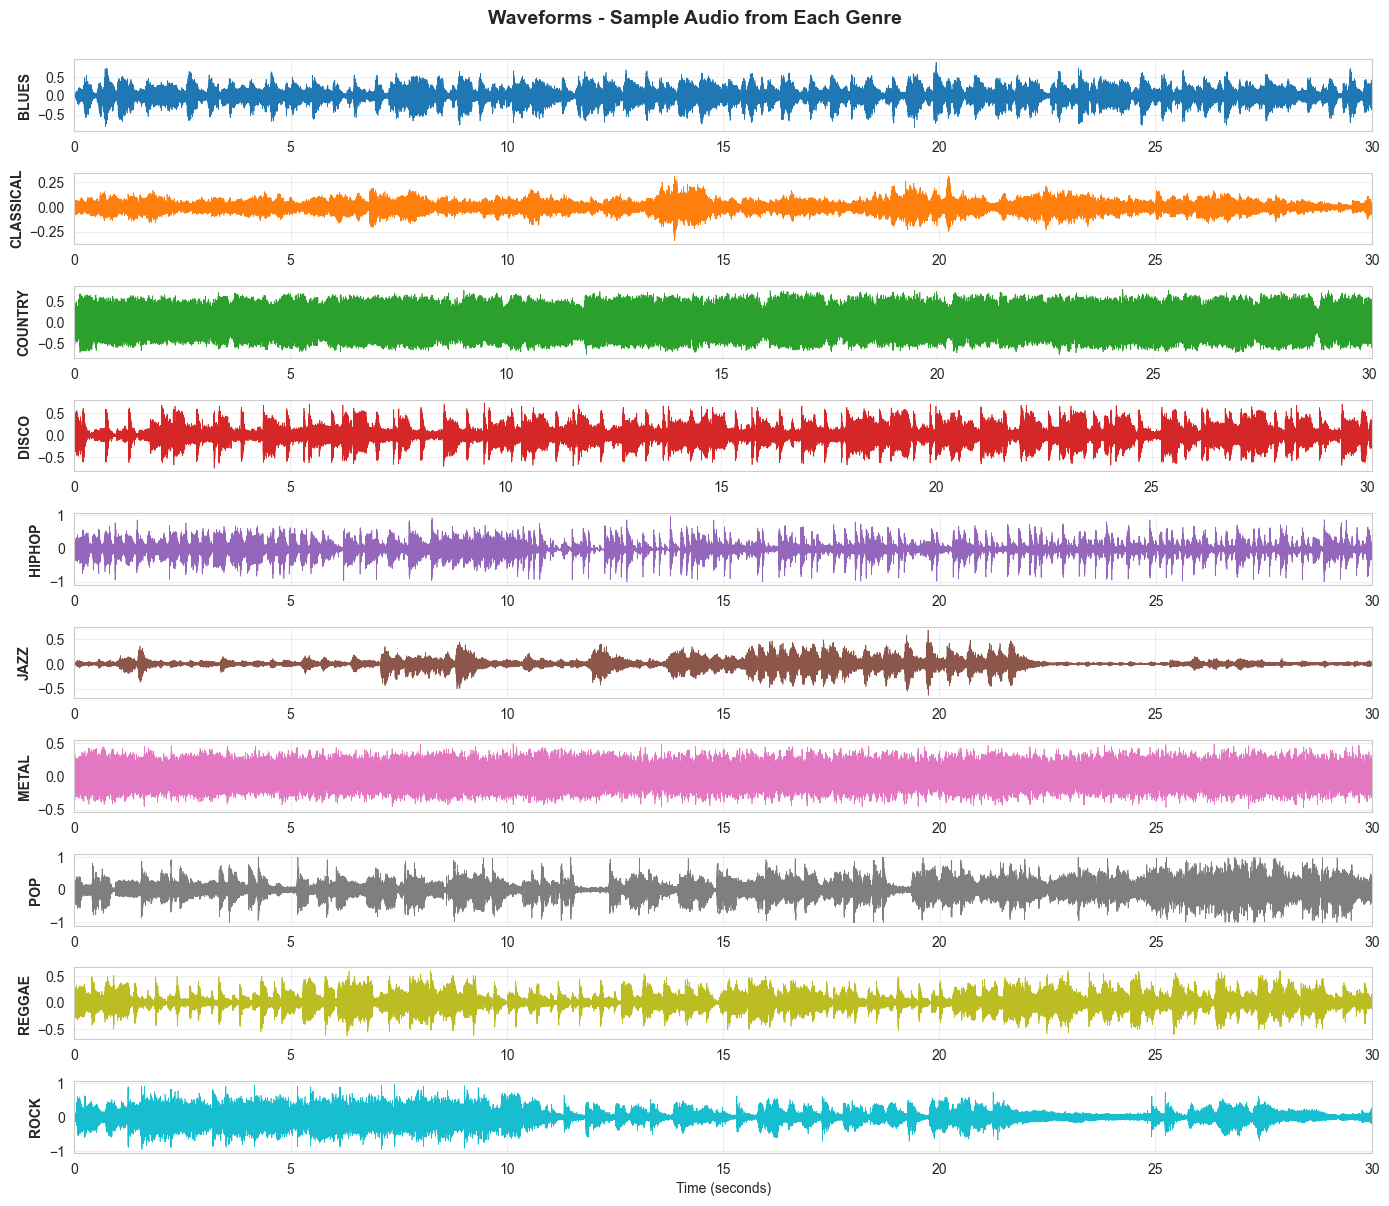

✓ Waveform visualization complete


In [7]:
# EDA: Visualize sample waveforms from each genre
fig, axes = plt.subplots(len(genres), 1, figsize=(14, 12))

for idx, genre in enumerate(genres):
    genre_path = os.path.join(data_dir, genre)
    wav_files = [f for f in os.listdir(genre_path) if f.endswith('.wav')]
    
    if wav_files:
        # Load first file from genre
        file_path = os.path.join(genre_path, wav_files[0])
        y, sr = librosa.load(file_path, sr=None)
        
        # Time axis in seconds
        time = np.arange(len(y)) / sr
        
        axes[idx].plot(time, y, linewidth=0.5, color=f'C{idx}')
        axes[idx].set_ylabel(genre.upper(), fontsize=10, fontweight='bold')
        axes[idx].set_xlim([0, time[-1]])
        axes[idx].grid(True, alpha=0.3)
        
        if idx == len(genres) - 1:
            axes[idx].set_xlabel('Time (seconds)', fontsize=10)

plt.suptitle('Waveforms - Sample Audio from Each Genre', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

print("✓ Waveform visualization complete")

In [8]:
# Extract MFCC Features
print("Extracting MFCC features from all audio files...")

mfcc_data = []
n_mfcc = 13  # Number of MFCC coefficients

for idx, row in df.iterrows():
    genre = row['Genre']
    filename = row['Filename']
    file_path = os.path.join(data_dir, genre, filename)
    
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=None)
        
        # Extract MFCC
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        
        # Calculate statistics (mean, std, min, max)
        mfcc_stats = {}
        mfcc_stats['Genre'] = genre
        mfcc_stats['Filename'] = filename
        
        for i in range(n_mfcc):
            mfcc_stats[f'MFCC_{i}_mean'] = np.mean(mfcc[i])
            mfcc_stats[f'MFCC_{i}_std'] = np.std(mfcc[i])
            mfcc_stats[f'MFCC_{i}_min'] = np.min(mfcc[i])
            mfcc_stats[f'MFCC_{i}_max'] = np.max(mfcc[i])
        
        mfcc_data.append(mfcc_stats)
        
        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(df)} files...")
    
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Create MFCC DataFrame
df_mfcc = pd.DataFrame(mfcc_data)
print(f"\n✓ MFCC extraction complete!")
print(f"Shape of MFCC features: {df_mfcc.shape}")
print(f"\nFirst few rows of MFCC data:")
print(df_mfcc.head())

Extracting MFCC features from all audio files...
  Processed 50/999 files...
  Processed 100/999 files...
  Processed 150/999 files...
  Processed 200/999 files...
  Processed 250/999 files...
  Processed 300/999 files...
  Processed 350/999 files...
  Processed 400/999 files...
  Processed 450/999 files...
  Processed 500/999 files...
  Processed 550/999 files...
  Processed 600/999 files...
  Processed 650/999 files...
  Processed 700/999 files...
  Processed 750/999 files...
  Processed 800/999 files...
  Processed 850/999 files...
  Processed 900/999 files...
  Processed 950/999 files...

✓ MFCC extraction complete!
Shape of MFCC features: (999, 54)

First few rows of MFCC data:
   Genre         Filename  MFCC_0_mean  MFCC_0_std  MFCC_0_min  MFCC_0_max  \
0  blues  blues.00000.wav  -113.598824   50.688946 -257.911011   21.742056   
1  blues  blues.00001.wav  -207.523834   88.142525 -448.555634  -25.956675   
2  blues  blues.00002.wav   -90.757164   57.601101 -343.934814   32.401398

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

1. ANALISIS KORELASI ANTAR FITUR MFCC


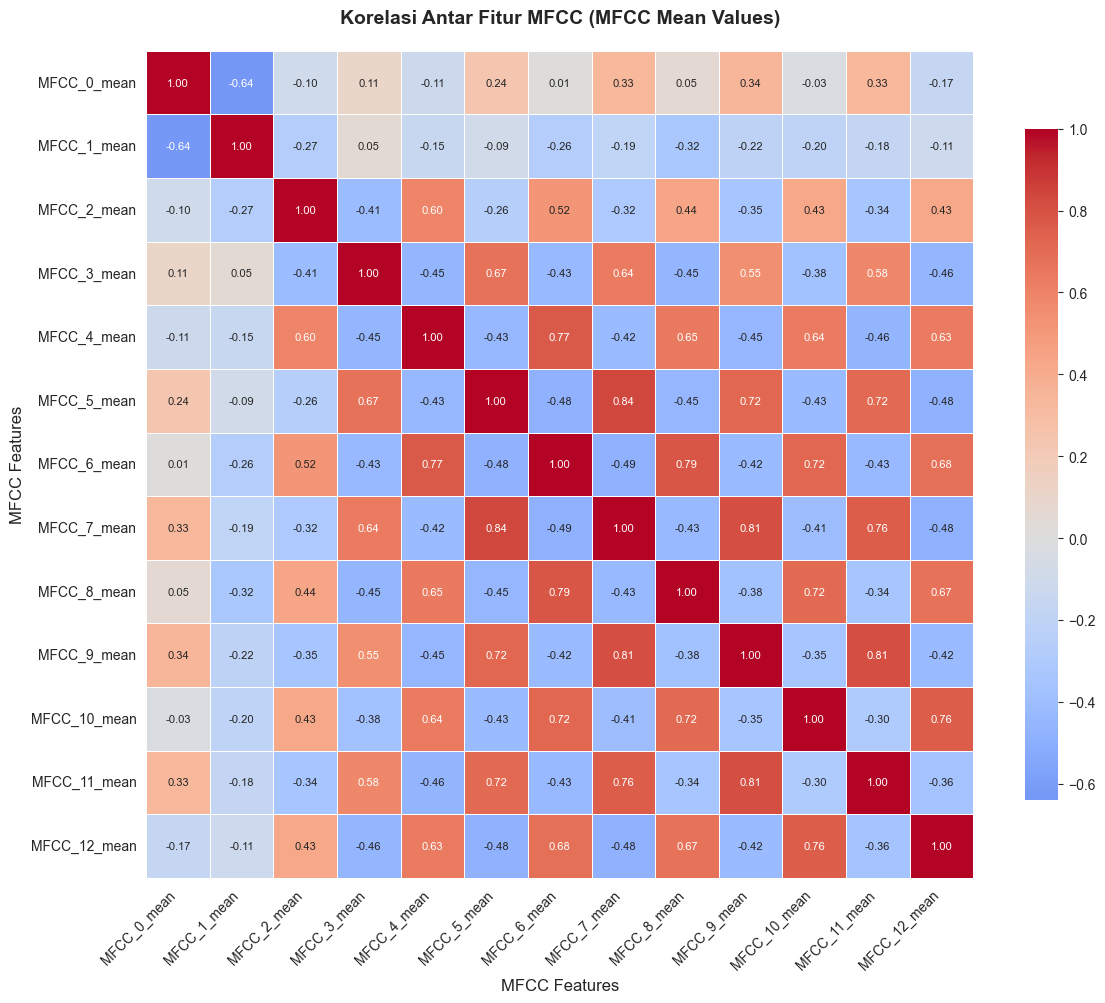

✓ Heatmap korelasi selesai!



In [18]:
# ============================================================
# 1. KORELASI ANTAR FITUR MFCC - CORRELATION HEATMAP
# ============================================================
print("=" * 80)
print("1. ANALISIS KORELASI ANTAR FITUR MFCC")
print("=" * 80)

# Ambil hanya kolom MFCC_mean untuk correlation
mfcc_mean_cols = [col for col in df_mfcc.columns if 'mean' in col]
correlation_matrix = df_mfcc[mfcc_mean_cols].corr()

# Buat heatmap korelasi
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            fmt='.2f', annot_kws={'size': 8})
plt.title('Korelasi Antar Fitur MFCC (MFCC Mean Values)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('MFCC Features', fontsize=12)
plt.ylabel('MFCC Features', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("✓ Heatmap korelasi selesai!\n")


2. DISTRIBUSI FITUR MFCC MEAN PER GENRE


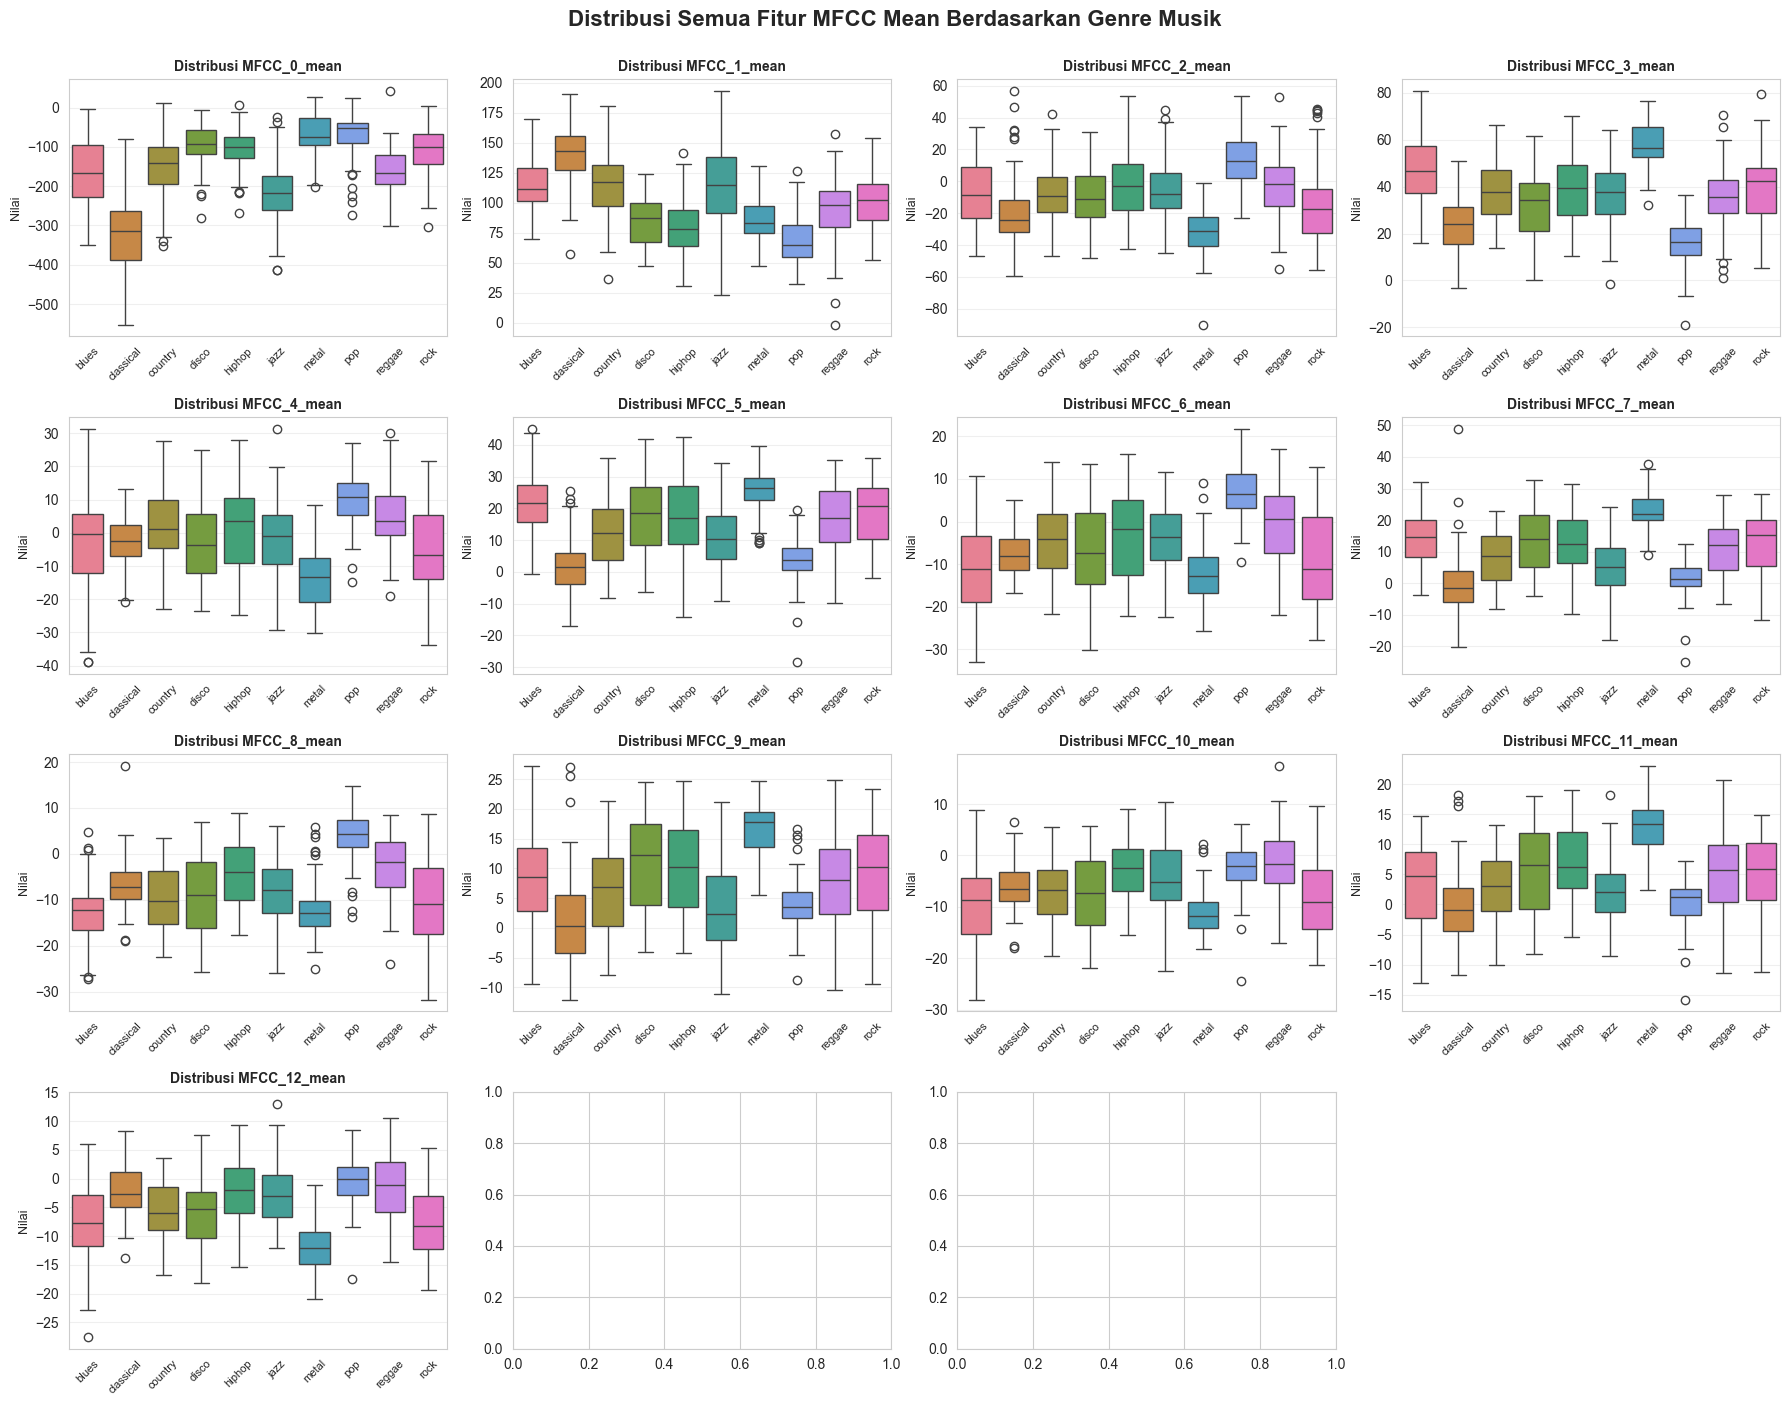

✓ Distribusi fitur selesai!



In [19]:
# ============================================================
# 2. DISTRIBUSI SEMUA FITUR MFCC MEAN BERDASARKAN GENRE
# ============================================================
print("=" * 80)
print("2. DISTRIBUSI FITUR MFCC MEAN PER GENRE")
print("=" * 80)

# Buat subplot untuk setiap MFCC mean feature
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(mfcc_mean_cols):
    ax = axes[idx]
    sns.boxplot(x='Genre', y=col, data=df_mfcc, palette='husl', ax=ax)
    ax.set_title(f'Distribusi {col}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Nilai', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(axis='y', alpha=0.3)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('Distribusi Semua Fitur MFCC Mean Berdasarkan Genre Musik', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ Distribusi fitur selesai!\n")


3. PAIR PLOT - RELASI ANTAR FITUR MFCC UTAMA


<Figure size 1400x1200 with 0 Axes>

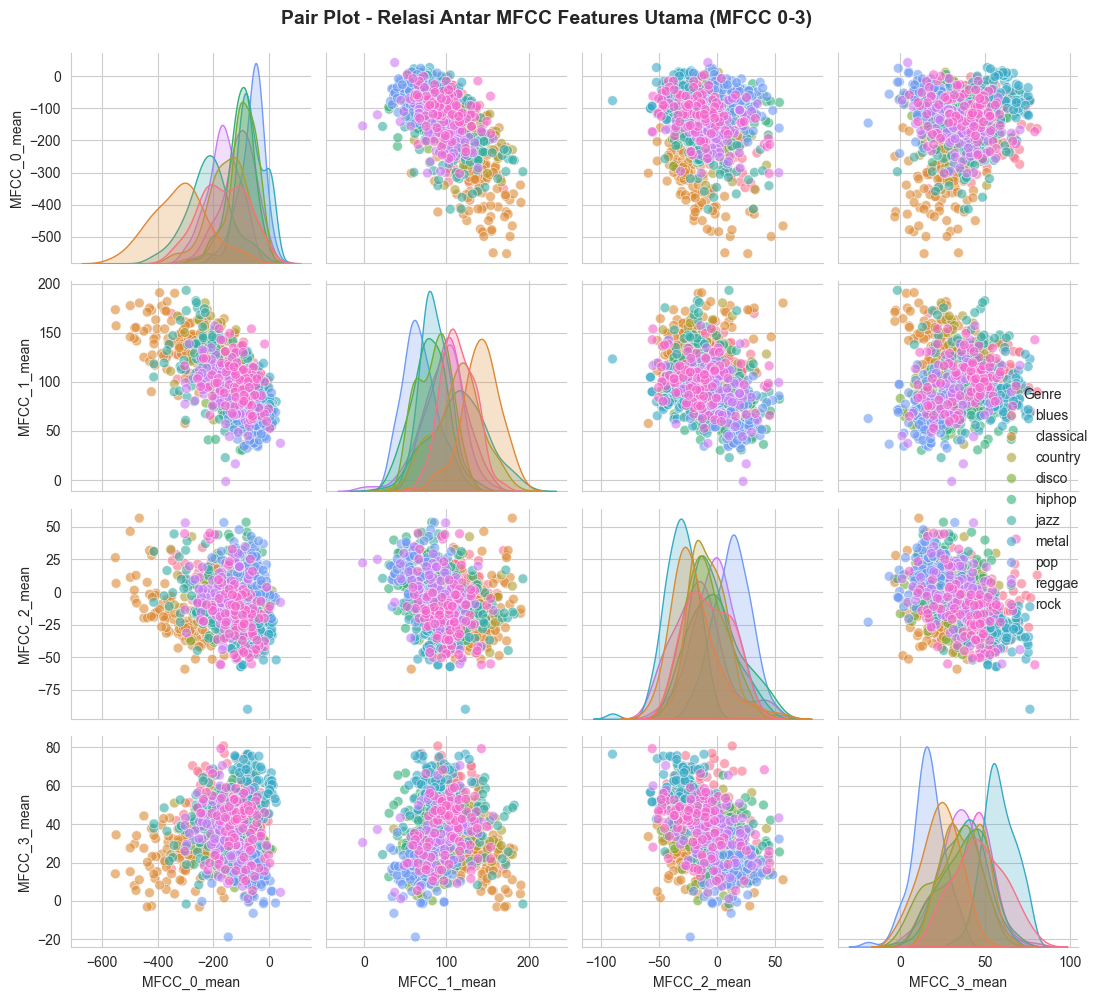

✓ Pair plot selesai!



In [13]:
# ============================================================
# 3. PAIR PLOT - RELASI ANTAR FITUR UTAMA
# ============================================================
print("=" * 80)
print("3. PAIR PLOT - RELASI ANTAR FITUR MFCC UTAMA")
print("=" * 80)

# Ambil fitur-fitur utama untuk pair plot
main_features = ['MFCC_0_mean', 'MFCC_1_mean', 'MFCC_2_mean', 'MFCC_3_mean', 'Genre']
df_main = df_mfcc[main_features].copy()

# Buat pair plot dengan warna berdasarkan genre
plt.figure(figsize=(14, 12))
pairplot = sns.pairplot(df_main, hue='Genre', diag_kind='kde', 
                        plot_kws={'alpha': 0.6, 's': 50},
                        palette='husl')
pairplot.fig.suptitle('Pair Plot - Relasi Antar MFCC Features Utama (MFCC 0-3)', 
                      fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Pair plot selesai!\n")


4. 3D SCATTER PLOT - MFCC FEATURES


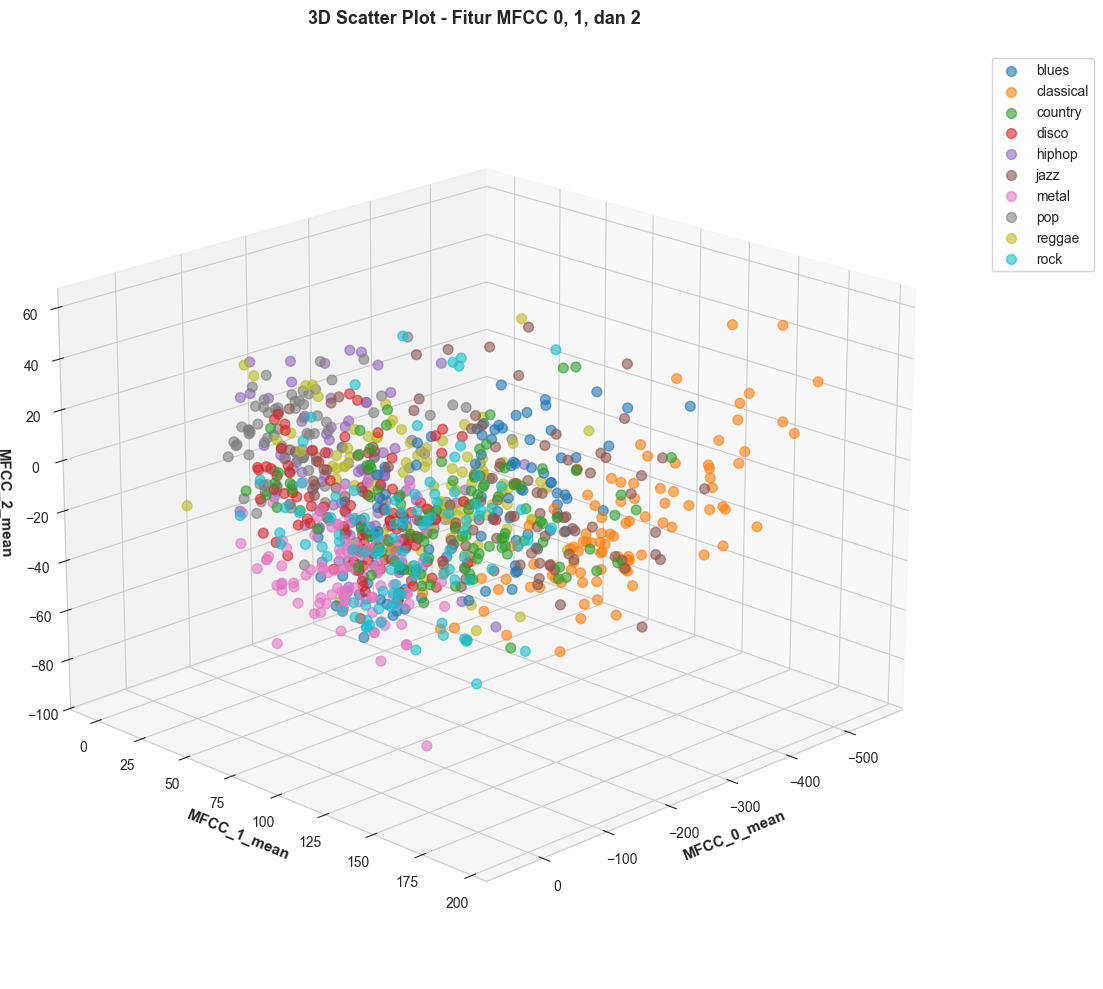

✓ 3D scatter plot selesai!



In [14]:
# ============================================================
# 4. 3D SCATTER PLOT - VISUALISASI MULTIDIMENSIONAL
# ============================================================
print("=" * 80)
print("4. 3D SCATTER PLOT - MFCC FEATURES")
print("=" * 80)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Warna untuk setiap genre
colors = plt.cm.tab10(np.linspace(0, 1, len(genres)))
genre_colors = {genre: colors[i] for i, genre in enumerate(genres)}

# Plot setiap genre dengan warna berbeda
for genre in genres:
    genre_data = df_mfcc[df_mfcc['Genre'] == genre]
    ax.scatter(genre_data['MFCC_0_mean'], 
               genre_data['MFCC_1_mean'], 
               genre_data['MFCC_2_mean'],
               c=[genre_colors[genre]], 
               label=genre, 
               alpha=0.6, 
               s=50)

ax.set_xlabel('MFCC_0_mean', fontsize=11, fontweight='bold')
ax.set_ylabel('MFCC_1_mean', fontsize=11, fontweight='bold')
ax.set_zlabel('MFCC_2_mean', fontsize=11, fontweight='bold')
ax.set_title('3D Scatter Plot - Fitur MFCC 0, 1, dan 2', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

print("✓ 3D scatter plot selesai!\n")


5. ANALISIS VARIANS FITUR MFCC


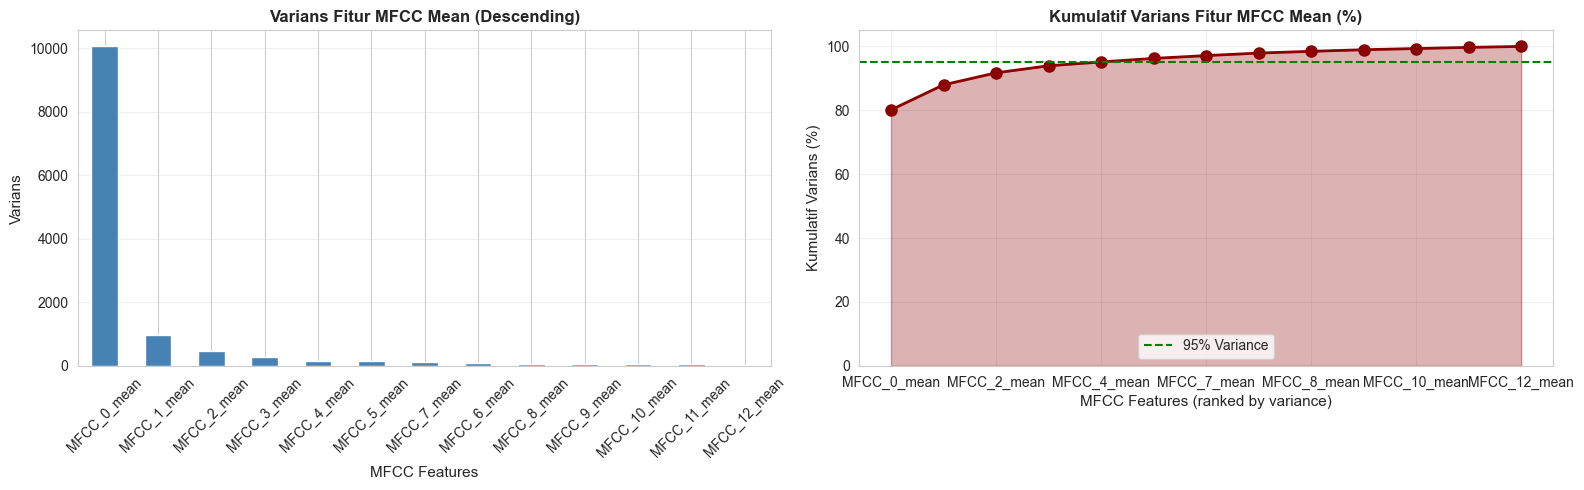


Top 5 Fitur dengan Varians Terbesar:
MFCC_0_mean    10052.785156
MFCC_1_mean      981.669617
MFCC_2_mean      470.786407
MFCC_3_mean      277.740051
MFCC_4_mean      149.482620
dtype: float32

✓ Analisis varians selesai!



In [15]:
# ============================================================
# 5. ANALISIS VARIANS DAN STATISTIK FITUR
# ============================================================
print("=" * 80)
print("5. ANALISIS VARIANS FITUR MFCC")
print("=" * 80)

# Hitung varians untuk setiap fitur
feature_variance = df_mfcc[mfcc_mean_cols].var().sort_values(ascending=False)

# Visualisasi varians
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Bar chart varians
ax1 = axes[0]
feature_variance.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Varians Fitur MFCC Mean (Descending)', fontsize=12, fontweight='bold')
ax1.set_xlabel('MFCC Features', fontsize=11)
ax1.set_ylabel('Varians', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Kumulatif varians
ax2 = axes[1]
cumulative_var = feature_variance.cumsum() / feature_variance.sum() * 100
cumulative_var.plot(kind='line', ax=ax2, marker='o', linewidth=2, markersize=8, color='darkred')
ax2.fill_between(range(len(cumulative_var)), cumulative_var, alpha=0.3, color='darkred')
ax2.set_title('Kumulatif Varians Fitur MFCC Mean (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('MFCC Features (ranked by variance)', fontsize=11)
ax2.set_ylabel('Kumulatif Varians (%)', fontsize=11)
ax2.set_ylim([0, 105])
ax2.grid(True, alpha=0.3)
ax2.axhline(y=95, color='green', linestyle='--', label='95% Variance')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nTop 5 Fitur dengan Varians Terbesar:")
print(feature_variance.head())
print("\n✓ Analisis varians selesai!\n")


6. SEPARABILITAS GENRE BERDASARKAN FITUR MFCC


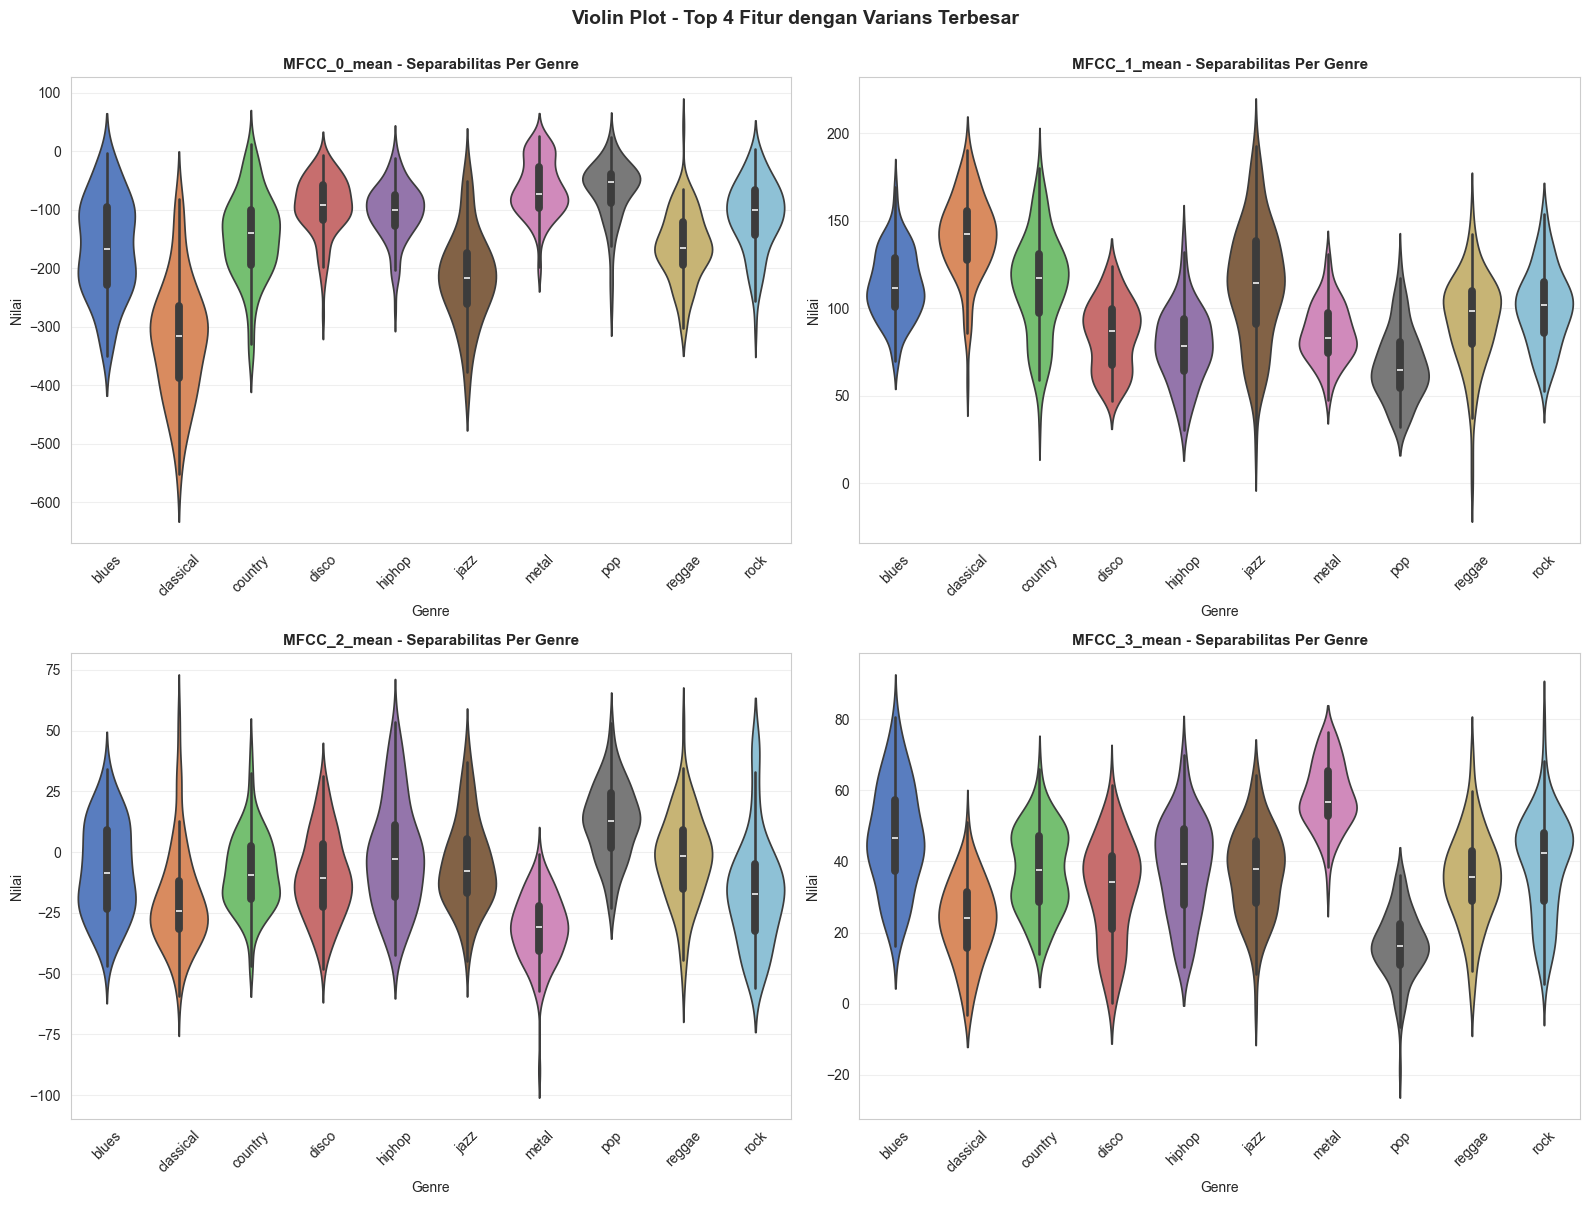

✓ Violin plot selesai!



In [16]:
# ============================================================
# 6. FEATURE SEPARABILITY - VIOLIN PLOT
# ============================================================
print("=" * 80)
print("6. SEPARABILITAS GENRE BERDASARKAN FITUR MFCC")
print("=" * 80)

# Buat violin plot untuk top 4 fitur dengan varians terbesar
top_features = feature_variance.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    sns.violinplot(x='Genre', y=feature, data=df_mfcc, palette='muted', ax=ax)
    ax.set_title(f'{feature} - Separabilitas Per Genre', fontsize=11, fontweight='bold')
    ax.set_xlabel('Genre', fontsize=10)
    ax.set_ylabel('Nilai', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Violin Plot - Top 4 Fitur dengan Varians Terbesar', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ Violin plot selesai!\n")


7. RINGKASAN STATISTIK DAN INSIGHTS

📊 STATISTIK DESKRIPTIF FITUR MFCC_0_mean PER GENRE:
--------------------------------------------------------------------------------
                 mean         std         min        max
Genre                                                   
blues     -164.608002   84.611000 -350.352997  -2.543000
classical -320.066010  101.387001 -552.158997 -81.114998
country   -145.044998   73.011002 -353.091003  12.146000
disco      -93.748001   50.325001 -280.854004  -6.765000
hiphop    -103.022003   48.382000 -268.937012   5.627000
jazz      -215.606003   78.847000 -414.083008 -23.792999
metal      -63.098999   48.243999 -201.197998  26.653000
pop        -67.889999   52.615002 -273.317993  24.325001
reggae    -162.578995   60.333000 -301.497009  42.091000
rock      -110.349998   61.148998 -302.824005   4.083000


🔗 TOP 10 KORELASI ANTAR FITUR (Tertinggi):
--------------------------------------------------------------------------------
   Feature 1    Feat

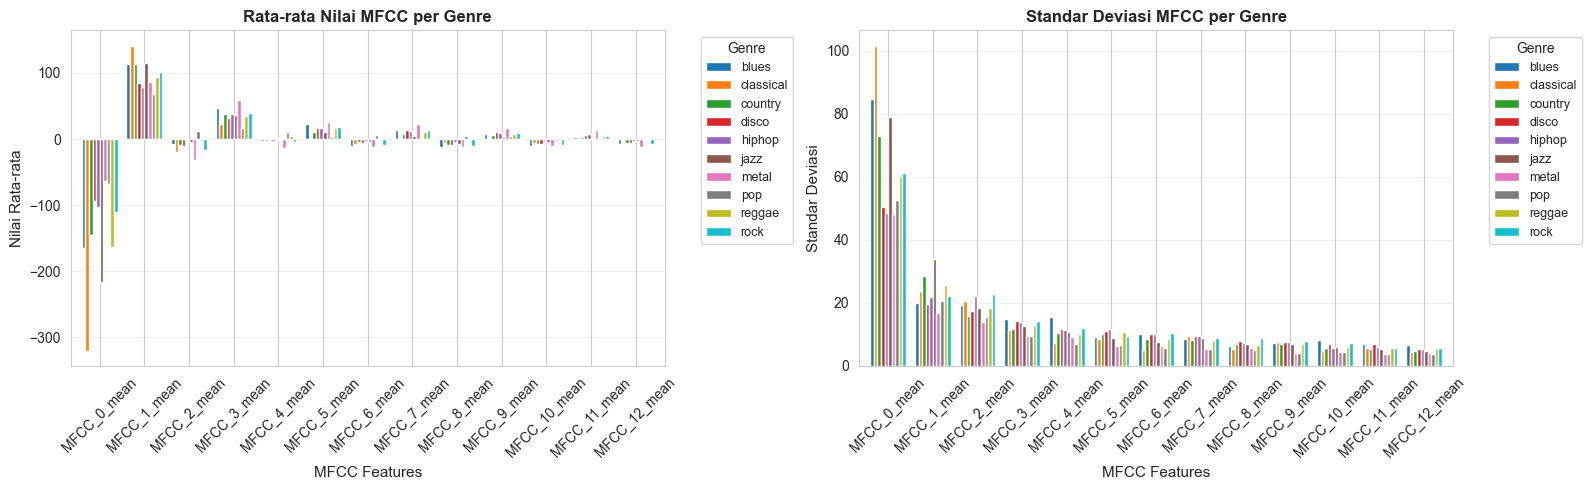


✓ Ringkasan analisis selesai!


📈 KEY INSIGHTS:
✓ Total sampel: 999 audio files
✓ Total genres: 10
✓ Total fitur MFCC: 13
✓ Fitur paling diskriminatif: MFCC_0_mean
✓ Korelasi fitur tertinggi: MFCC_5_mean - MFCC_7_mean = 0.837
✓ Korelasi fitur terendah: MFCC_0_mean - MFCC_1_mean = -0.640



In [17]:
# ============================================================
# 7. RINGKASAN STATISTIK DAN INSIGHTS
# ============================================================
print("=" * 80)
print("7. RINGKASAN STATISTIK DAN INSIGHTS")
print("=" * 80)

# Statistik deskriptif per genre
print("\n📊 STATISTIK DESKRIPTIF FITUR MFCC_0_mean PER GENRE:")
print("-" * 80)
genre_stats = df_mfcc.groupby('Genre')[mfcc_mean_cols[0]].agg(['mean', 'std', 'min', 'max'])
print(genre_stats.round(3))

# Korelasi tertinggi dan terendah
print("\n\n🔗 TOP 10 KORELASI ANTAR FITUR (Tertinggi):")
print("-" * 80)
# Ambil korelasi di atas diagonal (untuk menghindari duplikat dan diagonal)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'Feature 1': correlation_matrix.columns[i],
            'Feature 2': correlation_matrix.columns[j],
            'Correlation': correlation_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False)
print(corr_df.head(10).to_string(index=False))

print("\n\n🔗 TOP 10 KORELASI ANTAR FITUR (Terendah):")
print("-" * 80)
print(corr_df.tail(10).to_string(index=False))

# Visualisasi summary statistics
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Mean values per genre
ax1 = axes[0]
df_mean = df_mfcc.groupby('Genre')[mfcc_mean_cols].mean()
df_mean.T.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('Rata-rata Nilai MFCC per Genre', fontsize=12, fontweight='bold')
ax1.set_xlabel('MFCC Features', fontsize=11)
ax1.set_ylabel('Nilai Rata-rata', fontsize=11)
ax1.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Std values per genre
ax2 = axes[1]
df_std = df_mfcc.groupby('Genre')[mfcc_mean_cols].std()
df_std.T.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title('Standar Deviasi MFCC per Genre', fontsize=12, fontweight='bold')
ax2.set_xlabel('MFCC Features', fontsize=11)
ax2.set_ylabel('Standar Deviasi', fontsize=11)
ax2.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Ringkasan analisis selesai!\n")

# Print summary insights
print("\n" + "=" * 80)
print("📈 KEY INSIGHTS:")
print("=" * 80)
print(f"✓ Total sampel: {len(df_mfcc)} audio files")
print(f"✓ Total genres: {len(genres)}")
print(f"✓ Total fitur MFCC: {len(mfcc_mean_cols)}")
print(f"✓ Fitur paling diskriminatif: {feature_variance.index[0]}")
print(f"✓ Korelasi fitur tertinggi: {corr_df.iloc[0]['Feature 1']} - {corr_df.iloc[0]['Feature 2']} = {corr_df.iloc[0]['Correlation']:.3f}")
print(f"✓ Korelasi fitur terendah: {corr_df.iloc[-1]['Feature 1']} - {corr_df.iloc[-1]['Feature 2']} = {corr_df.iloc[-1]['Correlation']:.3f}")
print("=" * 80 + "\n")
